# 分類（Classification）アイリスの花の分類

scikit-learn に内蔵されている **アイリスデータセット** を使って、花の種類を分類します。

| ステップ | 内容 |
|----------|------|
| 1 | データの読み込み・確認 |
| 2 | 学習用・テスト用に分割 |
| 3 | 前処理（標準化） |
| 4 | モデルの学習 |
| 5 | 予測・評価 |
| 6 | 可視化 |

## 1. データの読み込み・確認

In [10]:
from sklearn.datasets import load_iris
import pandas as pd

# アイリスデータセットを読み込む
iris = load_iris()
X = iris.data    # 特徴量: がく・花びらの長さ・幅 (150件 x 4列)
y = iris.target  # ラベル: 0=setosa, 1=versicolor, 2=virginica

# DataFrameで見やすく表示
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]
print("データ形状:", X.shape)
df.head(10)

データ形状: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [11]:
# 各クラスの件数確認
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 2. 学習用・テスト用に分割（8:2）

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("学習データ:", X_train.shape)
print("テストデータ:", X_test.shape)

学習データ: (120, 4)
テストデータ: (30, 4)


## 3. 前処理（標準化）

特徴量のスケールを揃えて、モデルが正しく学習できるようにします。  
**注意:** `fit_transform` は学習データにだけ使い、テストデータは `transform` のみ使います。

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # 学習データで平均・分散を計算して変換
X_test  = scaler.transform(X_test)       # テストデータは変換のみ（計算はしない）

## 4. モデルの学習

**K近傍法（KNN）** を使います。  
近くにある k 個のデータの多数決で分類するシンプルなアルゴリズムです。

In [14]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

print("学習完了")

学習完了


## 5. 予測・評価

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("正解率:", accuracy_score(y_test, y_pred))
print()
print("詳細レポート:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

正解率: 1.0

詳細レポート:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 6. 可視化

/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/2332983861.py:24: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing

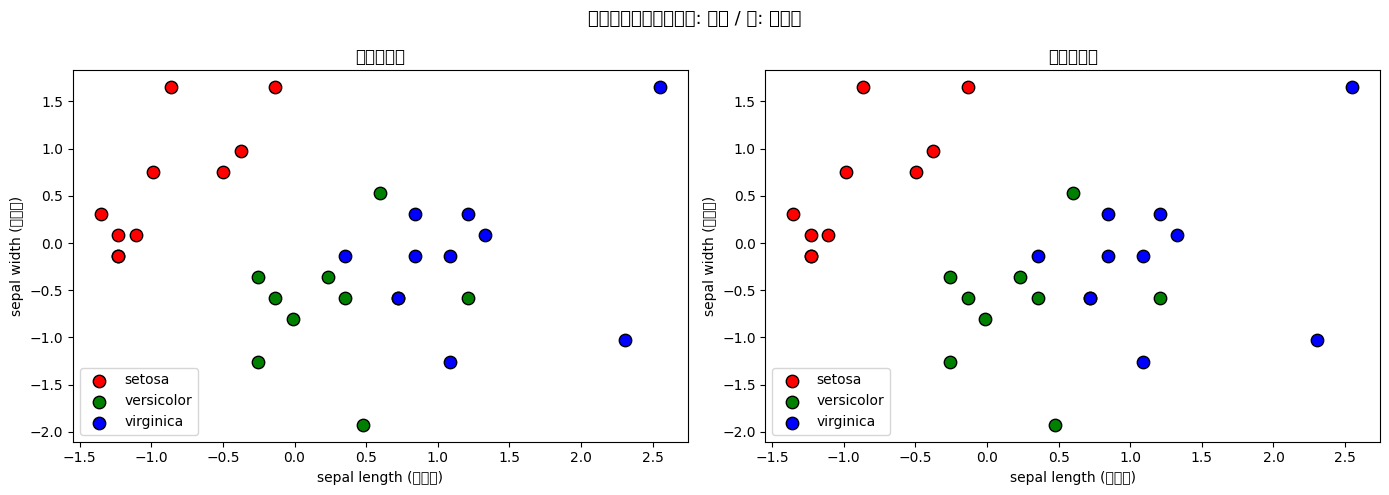

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- 6-1. テストデータの分類結果 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['red', 'green', 'blue']

for ax, (title, labels) in zip(axes, [
    ("正解ラベル", y_test),
    ("予測ラベル", y_pred)
]):
    for i, color in enumerate(colors):
        idx = np.where(labels == i)
        ax.scatter(
            X_test[idx, 0], X_test[idx, 1],
            color=color, label=iris.target_names[i], edgecolors='k', s=80
        )
    ax.set_xlabel("sepal length (標準化)")
    ax.set_ylabel("sepal width (標準化)")
    ax.set_title(title)
    ax.legend()

plt.suptitle("アイリス分類結果（左: 正解 / 右: 予測）", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13524/3423300546.py:12: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/3423300546.py:12: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/3423300546.py:12: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13524/3423300546.py:12: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/401_scikit-learn/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/HOME/sample/sample_python/401_scikit-learn/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2

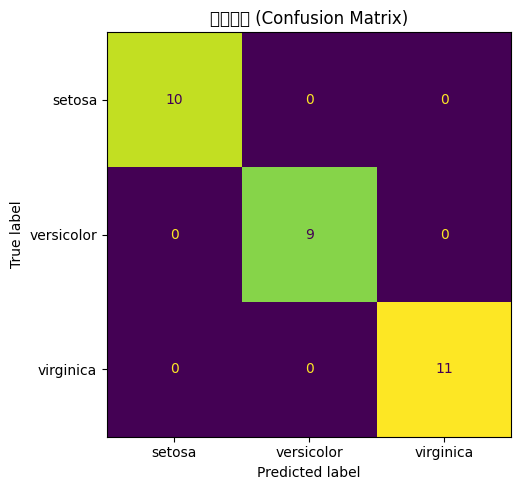

In [17]:
# --- 6-2. 混同行列（Confusion Matrix）---
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    ax=ax,
    colorbar=False
)
ax.set_title("混同行列 (Confusion Matrix)")
plt.tight_layout()
plt.show()